In [ ]:
!pip install -q kagglehub kagglehub[pandas-datasets] pandas

In [ ]:
import os
import glob
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

def list_all_files(folder_path):
    all_files = []
    for root, dirs, files in os.walk(folder_path):
        for f in files:
            all_files.append(os.path.join(root, f))
    return sorted(all_files)

def find_tabular_files(folder_path):
    patterns = ["**/*.csv", "**/*.xlsx", "**/*.xls", "**/*.json", "**/*.parquet"]
    files = []
    for p in patterns:
        files.extend(glob.glob(os.path.join(folder_path, p), recursive=True))
    return sorted(files)

def load_file_auto(file_path):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        try:
            return pd.read_csv(file_path)
        except:
            try:
                return pd.read_csv(file_path, encoding="utf-8-sig")
            except:
                return pd.read_csv(file_path, encoding="latin1")

    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)

    elif ext == ".json":
        return pd.read_json(file_path)

    elif ext == ".parquet":
        return pd.read_parquet(file_path)

    else:
        raise ValueError(f"Unsupported file type: {ext}")

def download_and_inspect(dataset_name, dataset_label):
    print("=" * 80)
    print(f"DOWNLOADING: {dataset_label}")
    print(f"Kaggle dataset: {dataset_name}")

    path = kagglehub.dataset_download(dataset_name)
    print("\nLocal path:")
    print(path)

    print("\nAll files found:")
    all_files = list_all_files(path)
    for f in all_files:
        print(f)

    tabular_files = find_tabular_files(path)
    print("\nTabular files found:")
    for i, f in enumerate(tabular_files):
        print(f"[{i}] {f}")

    if len(tabular_files) == 0:
        print("\nNo CSV/Excel/JSON/Parquet file found.")
        return path, None, None

    selected_file = tabular_files[0]
    print(f"\nLoading first detected tabular file:\n{selected_file}")

    df = load_file_auto(selected_file)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst 5 rows:")
    display(df.head())

    return path, selected_file, df

In [ ]:
english_path, english_file, df_english = download_and_inspect(
    "clmentbisaillon/fake-and-real-news-dataset",
    "English Fake and Real News Dataset"
)

DOWNLOADING: English Fake and Real News Dataset
Kaggle dataset: clmentbisaillon/fake-and-real-news-dataset
Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.

Local path:
/kaggle/input/fake-and-real-news-dataset

All files found:
/kaggle/input/fake-and-real-news-dataset/Fake.csv
/kaggle/input/fake-and-real-news-dataset/True.csv

Tabular files found:
[0] /kaggle/input/fake-and-real-news-dataset/Fake.csv
[1] /kaggle/input/fake-and-real-news-dataset/True.csv

Loading first detected tabular file:
/kaggle/input/fake-and-real-news-dataset/Fake.csv

Shape:
(23481, 4)

Columns:
['title', 'text', 'subject', 'date']

First 5 rows:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
english_tabular_files = find_tabular_files(english_path)
print(english_tabular_files)

df_en_1 = load_file_auto(english_tabular_files[0])
df_en_2 = load_file_auto(english_tabular_files[1])

print("File 1 shape:", df_en_1.shape)
print("File 2 shape:", df_en_2.shape)

display(df_en_1.head())
display(df_en_2.head())

['/kaggle/input/fake-and-real-news-dataset/Fake.csv', '/kaggle/input/fake-and-real-news-dataset/True.csv']
File 1 shape: (23481, 4)
File 2 shape: (21417, 4)


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
# Load both English files
df_en_1 = load_file_auto(english_tabular_files[0])   # File 1 = fake
df_en_2 = load_file_auto(english_tabular_files[1])   # File 2 = true

# Add labels manually as you confirmed
df_en_1["label"] = "fake"
df_en_2["label"] = "true"

# Add language column
df_en_1["language"] = "english"
df_en_2["language"] = "english"

# Combine both
df_english = pd.concat([df_en_1, df_en_2], ignore_index=True)

# Reset index
df_english.reset_index(drop=True, inplace=True)

# Check result
print("Combined English dataset shape:", df_english.shape)
print("\nLabel distribution:")
print(df_english["label"].value_counts())

display(df_english.head())

Combined English dataset shape: (44898, 6)

Label distribution:
label
fake    23481
true    21417
Name: count, dtype: int64


,title,text,subject,date,label,language
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",fake,english
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",fake,english
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",fake,english
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",fake,english
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",fake,english


In [ ]:
bengali_path, bengali_file, df_bengali = download_and_inspect(
    "musfiqurtuhin/bengali-fake-news-detection-dataset",
    "Bengali Fake News Detection Dataset"
)

DOWNLOADING: Bengali Fake News Detection Dataset
Kaggle dataset: musfiqurtuhin/bengali-fake-news-detection-dataset


100%|██████████| 12.5M/12.5M [00:00<00:00, 71.0MB/s]

Extracting files...



Local path:
/root/.cache/kagglehub/datasets/musfiqurtuhin/bengali-fake-news-detection-dataset/versions/2

All files found:
/root/.cache/kagglehub/datasets/musfiqurtuhin/bengali-fake-news-detection-dataset/versions/2/Bengali-Fake-News-Dataset 2/bengali_fake_news.csv

Tabular files found:
[0] /root/.cache/kagglehub/datasets/musfiqurtuhin/bengali-fake-news-detection-dataset/versions/2/Bengali-Fake-News-Dataset 2/bengali_fake_news.csv

Loading first detected tabular file:
/root/.cache/kagglehub/datasets/musfiqurtuhin/bengali-fake-news-detection-dataset/versions/2/Bengali-Fake-News-Dataset 2/bengali_fake_news.csv

Shape:
(11839, 4)

Columns:
['category', 'headline', 'content', 'label']

First 5 rows:


,category,headline,content,label
0,Education,১৪তম শিক্ষক নিবন্ধনের চূড়ান্ত ফল এ মাসে,চলতি মাসে ১৪তম শিক্ষক নিবন্ধন পরীক্ষার চূড়ান্ত...,1
1,National,মুন্সীগঞ্জে প্লাস্টিক কারখানায় আগুন,মুন্সীগঞ্জ সদরের কমলাঘাট বাণিজ্যিক বন্দরের একট...,1
2,National,নাগেশ্বরীতে ফেনসিডিলসহ দম্পতি আটক,কুড়িগ্রাম: কুড়িগ্রামের নাগেশ্বরী উপজেলায় ৩৭ বো...,1
3,International,পানের বরজে দুর্বৃত্তদের আগুন,রাজশাহীর দুর্গাপুরে পানের বরজে আগুন দিয়েছে দুর...,1
4,National,‘বন্দুকযুদ্ধে’ সারাদেশে নিহত ৩,"দ্য রিপোর্ট ডেস্ক : রাজধানী ঢাকার মিরপুর, সাভা...",1


In [ ]:
# Keep and rename required columns
df_bengali = df_bengali[["headline", "content", "label"]].copy()
df_bengali = df_bengali.rename(columns={
    "headline": "title",
    "content": "text"
})

# Relabel label column
df_bengali["label"] = df_bengali["label"].replace({
    1: "true",
    0: "fake"
})

# Add language column
df_bengali["language"] = "bengali"

# Reorder columns
df_bengali = df_bengali[["language", "title", "text", "label"]]

print("Bengali dataset shape:", df_bengali.shape)
print("\nLabel distribution:")
print(df_bengali["label"].value_counts())

display(df_bengali.head())

Bengali dataset shape: (11839, 4)

Label distribution:
label
true    6000
fake    5839
Name: count, dtype: int64


,language,title,text,label
0,bengali,১৪তম শিক্ষক নিবন্ধনের চূড়ান্ত ফল এ মাসে,চলতি মাসে ১৪তম শিক্ষক নিবন্ধন পরীক্ষার চূড়ান্ত...,true
1,bengali,মুন্সীগঞ্জে প্লাস্টিক কারখানায় আগুন,মুন্সীগঞ্জ সদরের কমলাঘাট বাণিজ্যিক বন্দরের একট...,true
2,bengali,নাগেশ্বরীতে ফেনসিডিলসহ দম্পতি আটক,কুড়িগ্রাম: কুড়িগ্রামের নাগেশ্বরী উপজেলায় ৩৭ বো...,true
3,bengali,পানের বরজে দুর্বৃত্তদের আগুন,রাজশাহীর দুর্গাপুরে পানের বরজে আগুন দিয়েছে দুর...,true
4,bengali,‘বন্দুকযুদ্ধে’ সারাদেশে নিহত ৩,"দ্য রিপোর্ট ডেস্ক : রাজধানী ঢাকার মিরপুর, সাভা...",true


In [ ]:
hindi_path, hindi_file, df_hindi = download_and_inspect(
    "arnavagrawal22/arnsin-dl-cleaned1",
    "Hindi Dataset"
)

DOWNLOADING: Hindi Dataset
Kaggle dataset: arnavagrawal22/arnsin-dl-cleaned1


100%|██████████| 6.96M/6.96M [00:00<00:00, 54.0MB/s]

Extracting files...



Local path:
/root/.cache/kagglehub/datasets/arnavagrawal22/arnsin-dl-cleaned1/versions/1

All files found:
/root/.cache/kagglehub/datasets/arnavagrawal22/arnsin-dl-cleaned1/versions/1/dataset-merged.csv

Tabular files found:
[0] /root/.cache/kagglehub/datasets/arnavagrawal22/arnsin-dl-cleaned1/versions/1/dataset-merged.csv

Loading first detected tabular file:
/root/.cache/kagglehub/datasets/arnavagrawal22/arnsin-dl-cleaned1/versions/1/dataset-merged.csv

Shape:
(17124, 4)

Columns:
['Unnamed: 0', 'text', 'label', 'wcount']

First 5 rows:


,Unnamed: 0,text,label,wcount
0,0,‘मोदी के शासन के दौरान गंगा’ गंगा नदी नरेन्द्...,1,19
1,1,यह खबर आने से पहले छवि क्रेडिट जस्टिन सुलिवान/...,1,374
2,2,गुलाब गेंद वाल डे-नाइट टेस्ट मैच कप्ता विराट क...,0,20
3,3,उत्तर कोरिया रॉकेट प्रक्षेपण योजनाएं 71 0 15 0...,1,345
4,4,राष्ट्रपति डोनाल्ड ट्रम्प और प्रथम महिला मेलान...,0,180


In [ ]:
# Keep only required columns
df_hindi = df_hindi[["text", "label"]].copy()

# Relabel label column
# 1 = Fake News, 0 = True News
df_hindi["label"] = df_hindi["label"].replace({
    1: "fake",
    0: "true"
})

# Add language column
df_hindi["language"] = "hindi"

# Optional: create empty title column so structure matches other datasets
df_hindi["title"] = ""

# Reorder columns
df_hindi = df_hindi[["language", "title", "text", "label"]]

# Check result
print("Hindi dataset shape:", df_hindi.shape)
print("\nLabel distribution:")
print(df_hindi["label"].value_counts())

display(df_hindi.head())

Hindi dataset shape: (17124, 4)

Label distribution:
label
true    9944
fake    7180
Name: count, dtype: int64


,language,title,text,label
0,hindi,,‘मोदी के शासन के दौरान गंगा’ गंगा नदी नरेन्द्...,fake
1,hindi,,यह खबर आने से पहले छवि क्रेडिट जस्टिन सुलिवान/...,fake
2,hindi,,गुलाब गेंद वाल डे-नाइट टेस्ट मैच कप्ता विराट क...,true
3,hindi,,उत्तर कोरिया रॉकेट प्रक्षेपण योजनाएं 71 0 15 0...,fake
4,hindi,,राष्ट्रपति डोनाल्ड ट्रम्प और प्रथम महिला मेलान...,true


In [ ]:
# Keep only required columns from English
df_english = df_english[["language", "title", "text", "label"]].copy()

# Make sure labels are consistent
df_english["label"] = df_english["label"].replace({
    "fake": "fake",
    "true": "true"
})

print("English shape:", df_english.shape)
print(df_english["label"].value_counts())
display(df_english.head())

English shape: (44898, 4)
label
fake    23481
true    21417
Name: count, dtype: int64


,language,title,text,label
0,english,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,fake
1,english,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,fake
2,english,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",fake
3,english,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",fake
4,english,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,fake


In [ ]:
# Bengali exact structure
df_bengali = df_bengali[["language", "title", "text", "label"]].copy()
df_bengali["label"] = df_bengali["label"].replace({
    "fake": "fake",
    "true": "true"
})

print("Bengali shape:", df_bengali.shape)
print(df_bengali["label"].value_counts())
display(df_bengali.head())


# Hindi exact structure
df_hindi = df_hindi[["language", "title", "text", "label"]].copy()
df_hindi["label"] = df_hindi["label"].replace({
    "fake": "fake",
    "true": "true"
})

print("Hindi shape:", df_hindi.shape)
print(df_hindi["label"].value_counts())
display(df_hindi.head())

Bengali shape: (11839, 4)
label
true    6000
fake    5839
Name: count, dtype: int64


,language,title,text,label
0,bengali,১৪তম শিক্ষক নিবন্ধনের চূড়ান্ত ফল এ মাসে,চলতি মাসে ১৪তম শিক্ষক নিবন্ধন পরীক্ষার চূড়ান্ত...,true
1,bengali,মুন্সীগঞ্জে প্লাস্টিক কারখানায় আগুন,মুন্সীগঞ্জ সদরের কমলাঘাট বাণিজ্যিক বন্দরের একট...,true
2,bengali,নাগেশ্বরীতে ফেনসিডিলসহ দম্পতি আটক,কুড়িগ্রাম: কুড়িগ্রামের নাগেশ্বরী উপজেলায় ৩৭ বো...,true
3,bengali,পানের বরজে দুর্বৃত্তদের আগুন,রাজশাহীর দুর্গাপুরে পানের বরজে আগুন দিয়েছে দুর...,true
4,bengali,‘বন্দুকযুদ্ধে’ সারাদেশে নিহত ৩,"দ্য রিপোর্ট ডেস্ক : রাজধানী ঢাকার মিরপুর, সাভা...",true


Hindi shape: (17124, 4)
label
true    9944
fake    7180
Name: count, dtype: int64


,language,title,text,label
0,hindi,,‘मोदी के शासन के दौरान गंगा’ गंगा नदी नरेन्द्...,fake
1,hindi,,यह खबर आने से पहले छवि क्रेडिट जस्टिन सुलिवान/...,fake
2,hindi,,गुलाब गेंद वाल डे-नाइट टेस्ट मैच कप्ता विराट क...,true
3,hindi,,उत्तर कोरिया रॉकेट प्रक्षेपण योजनाएं 71 0 15 0...,fake
4,hindi,,राष्ट्रपति डोनाल्ड ट्रम्प और प्रथम महिला मेलान...,true


In [ ]:
# Combine all datasets
df_combined = pd.concat(
    [df_english, df_bengali, df_hindi],
    ignore_index=True
)

print("Combined shape before cleaning:", df_combined.shape)
display(df_combined.head())

Combined shape before cleaning: (73861, 4)


,language,title,text,label
0,english,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,fake
1,english,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,fake
2,english,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",fake
3,english,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",fake
4,english,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,fake


In [ ]:
# Remove rows with missing text
df_combined = df_combined.dropna(subset=["text"])

# Convert title/text to string
df_combined["title"] = df_combined["title"].fillna("").astype(str)
df_combined["text"] = df_combined["text"].astype(str)

# Remove rows where text is empty after stripping spaces
df_combined = df_combined[df_combined["text"].str.strip() != ""]

# Drop duplicates based on title + text + label + language
df_combined = df_combined.drop_duplicates(
    subset=["language", "title", "text", "label"]
).reset_index(drop=True)

print("Combined shape after cleaning:", df_combined.shape)

Combined shape after cleaning: (66181, 4)


In [ ]:
print("Final columns:")
print(df_combined.columns.tolist())

print("\nLanguage distribution:")
print(df_combined["language"].value_counts())

print("\nLabel distribution:")
print(df_combined["label"].value_counts())

print("\nCross-tab: language vs label")
print(pd.crosstab(df_combined["language"], df_combined["label"]))

display(df_combined.head())

Final columns:
['language', 'title', 'text', 'label']

Language distribution:
language
english    38658
hindi      16933
bengali    10590
Name: count, dtype: int64

Label distribution:
label
true    37090
fake    29091
Name: count, dtype: int64

Cross-tab: language vs label
label      fake   true
language              
bengali    4591   5999
english   17462  21196
hindi      7038   9895


,language,title,text,label
0,english,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,fake
1,english,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,fake
2,english,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",fake
3,english,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",fake
4,english,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,fake


In [ ]:
df_combined["full_text"] = (df_combined["title"] + " " + df_combined["text"]).str.strip()
df_combined["word_count"] = df_combined["full_text"].apply(lambda x: len(str(x).split()))
df_combined["char_count"] = df_combined["full_text"].apply(lambda x: len(str(x)))

1) Language distribution

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


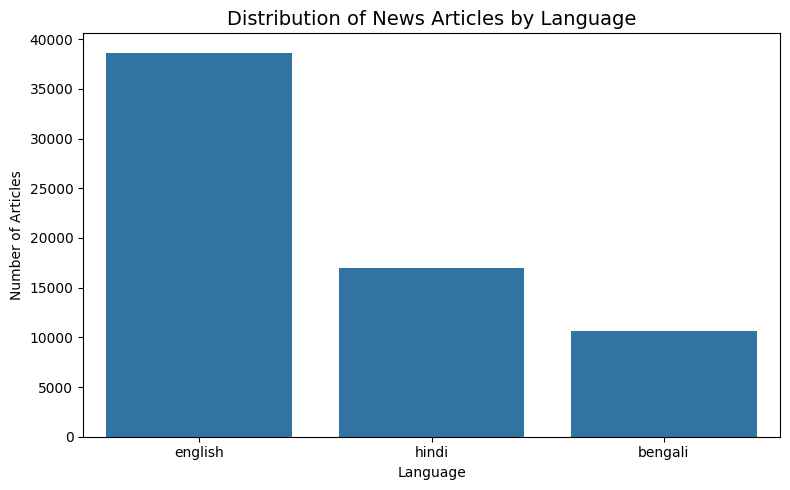

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_combined, x="language", order=df_combined["language"].value_counts().index)
plt.title("Distribution of News Articles by Language", fontsize=14)
plt.xlabel("Language")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

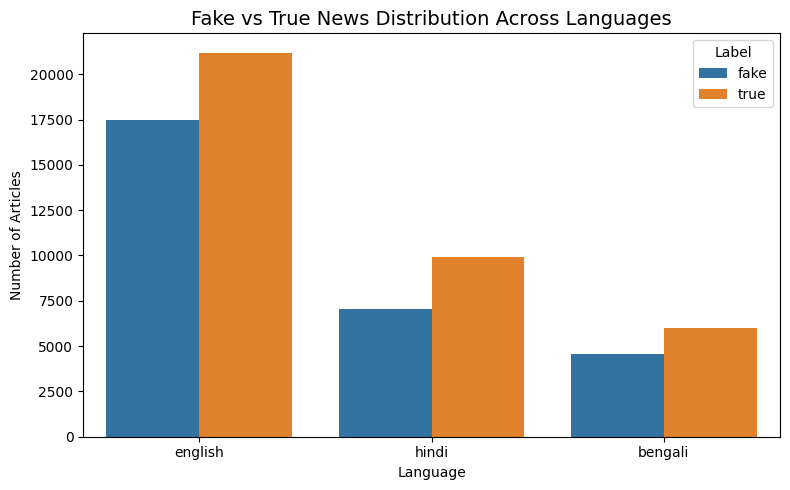

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_combined, x="language", hue="label", order=df_combined["language"].value_counts().index)
plt.title("Fake vs True News Distribution Across Languages", fontsize=14)
plt.xlabel("Language")
plt.ylabel("Number of Articles")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

3) Text length distribution by language using word count

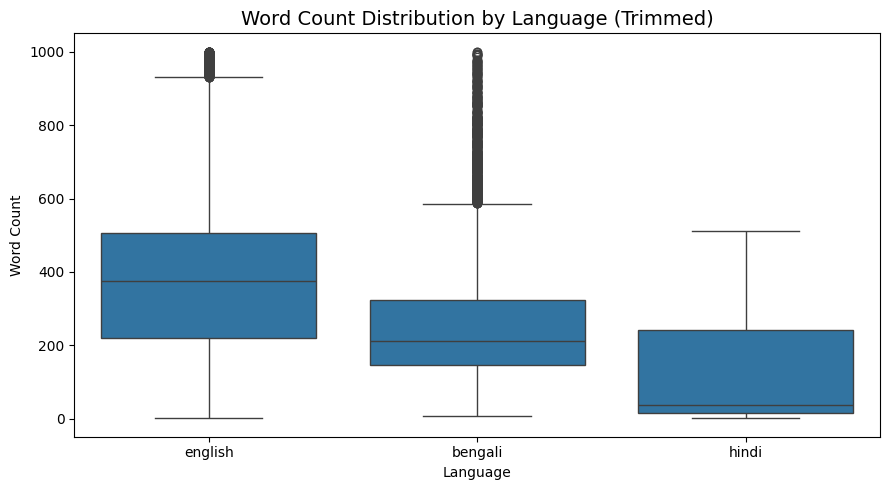

In [ ]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df_combined[df_combined["word_count"] <= 1000], x="language", y="word_count")
plt.title("Word Count Distribution by Language (Trimmed)", fontsize=14)
plt.xlabel("Language")
plt.ylabel("Word Count")
plt.tight_layout()
plt.show()

4) Top frequent words by language

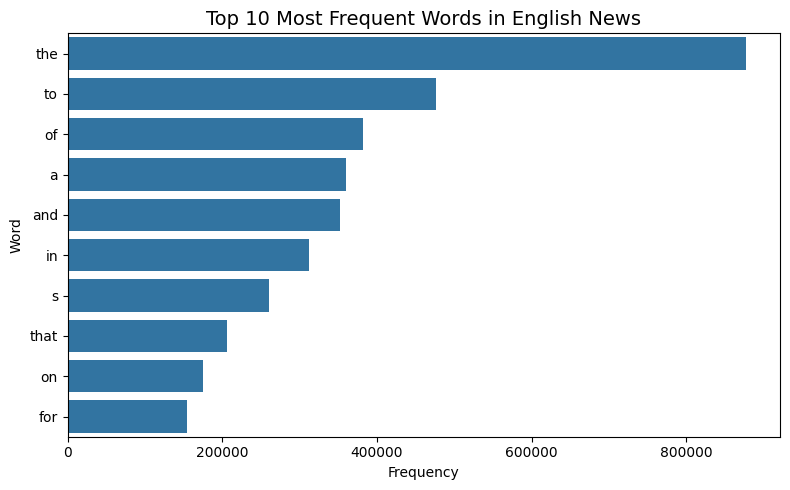

/tmp/ipykernel_1352/815762827.py:21: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1352/815762827.py:21: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipykernel_1352/815762827.py:21: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1352/815762827.py:21: UserWarning: Glyph 2468 (\N{BENGALI LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1352/815762827.py:21: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1352/815762827.py:21: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1352/815762827.py:21: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1352/815762827.py:

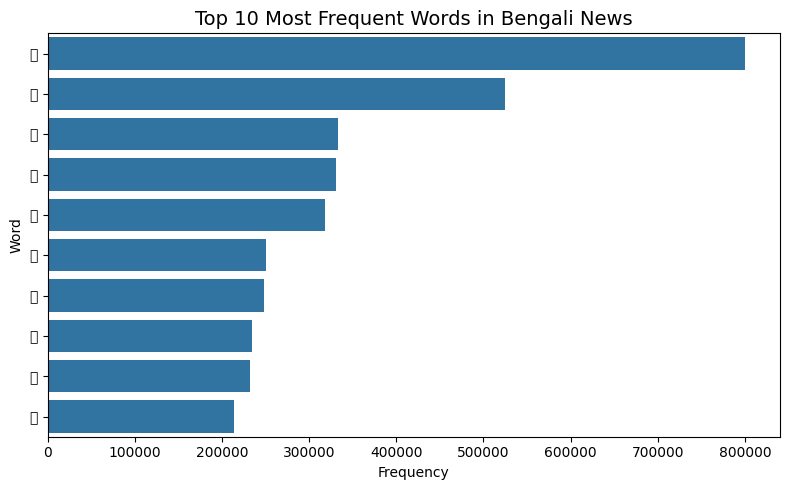

/tmp/ipykernel_1352/815762827.py:21: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1352/815762827.py:21: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_1352/815762827.py:21: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1352/815762827.py:21: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1352/815762827.py:21: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1352/815762827.py:21: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1352/815762827.py:21: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykern

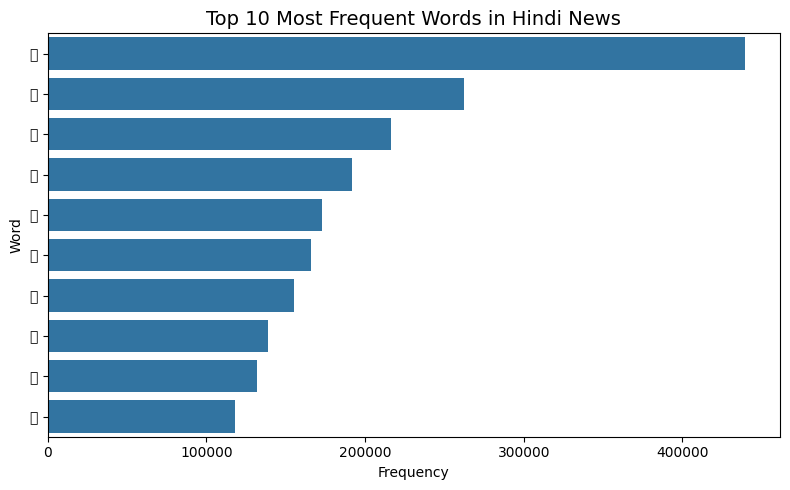

In [ ]:
from collections import Counter
import re

def get_top_words(text_series, n=10):
    words = " ".join(text_series.astype(str)).lower()
    words = re.findall(r"\w+", words)
    common_words = Counter(words).most_common(n)
    return pd.DataFrame(common_words, columns=["word", "count"])

languages = df_combined["language"].unique()

for lang in languages:
    temp_df = df_combined[df_combined["language"] == lang]
    top_words_df = get_top_words(temp_df["full_text"], n=10)

    plt.figure(figsize=(8,5))
    sns.barplot(data=top_words_df, x="count", y="word")
    plt.title(f"Top 10 Most Frequent Words in {lang.capitalize()} News", fontsize=14)
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# Create final input text
df_combined["full_text"] = (
    df_combined["title"].fillna("").astype(str) + " " +
    df_combined["text"].fillna("").astype(str)
).str.strip()

# Label encoding
df_combined["label_num"] = df_combined["label"].map({
    "true": 0,
    "fake": 1
})

# Keep only useful columns
df_model = df_combined[["language", "full_text", "label", "label_num"]].copy()

# Remove missing
df_model = df_model.dropna(subset=["full_text", "label_num"]).reset_index(drop=True)

print("Final modelling dataset shape:", df_model.shape)
print(df_model["label"].value_counts())
print(df_model["language"].value_counts())

display(df_model.head())

Final modelling dataset shape: (66181, 4)
label
true    37090
fake    29091
Name: count, dtype: int64
language
english    38658
hindi      16933
bengali    10590
Name: count, dtype: int64


,language,full_text,label,label_num
0,english,Donald Trump Sends Out Embarrassing New Year’s...,fake,1
1,english,Drunk Bragging Trump Staffer Started Russian C...,fake,1
2,english,Sheriff David Clarke Becomes An Internet Joke ...,fake,1
3,english,Trump Is So Obsessed He Even Has Obama’s Name ...,fake,1
4,english,Pope Francis Just Called Out Donald Trump Duri...,fake,1


In [ ]:
# First split: train and temp
train_df, temp_df = train_test_split(
    df_model,
    test_size=0.30,
    random_state=42,
    stratify=df_model["label_num"]
)

# Second split: validation and test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=222,
    stratify=temp_df["label_num"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain label distribution:")
print(train_df["label"].value_counts(normalize=True))

print("\nValidation label distribution:")
print(val_df["label"].value_counts(normalize=True))

print("\nTest label distribution:")
print(test_df["label"].value_counts(normalize=True))

Train shape: (46326, 4)
Validation shape: (9927, 4)
Test shape: (9928, 4)

Train label distribution:
label
true    0.560441
fake    0.439559
Name: proportion, dtype: float64

Validation label distribution:
label
true    0.560391
fake    0.439609
Name: proportion, dtype: float64

Test label distribution:
label
true    0.560435
fake    0.439565
Name: proportion, dtype: float64


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# Baseline pipeline
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=200))
])

# Train
baseline_model.fit(train_df["full_text"], train_df["label_num"])

# Validation predictions
val_preds_baseline = baseline_model.predict(val_df["full_text"])

# Metrics
val_acc = accuracy_score(val_df["label_num"], val_preds_baseline)
val_prec, val_rec, val_f1, _ = precision_recall_fscore_support(
    val_df["label_num"], val_preds_baseline, average="binary"
)

print("Baseline Validation Accuracy:", round(val_acc, 4))
print("Baseline Validation Precision:", round(val_prec, 4))
print("Baseline Validation Recall:", round(val_rec, 4))
print("Baseline Validation F1:", round(val_f1, 4))

print("\nClassification Report:")
print(classification_report(val_df["label_num"], val_preds_baseline, target_names=["true", "fake"]))

Baseline Validation Accuracy: 0.8963
Baseline Validation Precision: 0.9072
Baseline Validation Recall: 0.8513
Baseline Validation F1: 0.8784

Classification Report:
              precision    recall  f1-score   support

        true       0.89      0.93      0.91      5563
        fake       0.91      0.85      0.88      4364

    accuracy                           0.90      9927
   macro avg       0.90      0.89      0.89      9927
weighted avg       0.90      0.90      0.90      9927



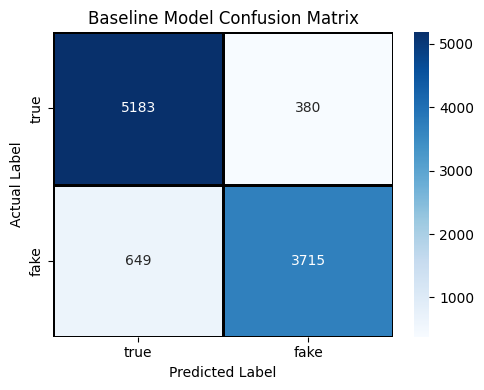

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(val_df["label_num"], val_preds_baseline)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["true", "fake"],
            yticklabels=["true", "fake"],
            linewidths=1, linecolor="black")
plt.title("Baseline Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [ ]:
!pip install -q transformers datasets accelerate evaluate sentencepiece gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


In [ ]:
from datasets import Dataset, DatasetDict

train_hf = Dataset.from_pandas(train_df[["full_text", "label_num"]].reset_index(drop=True))
val_hf = Dataset.from_pandas(val_df[["full_text", "label_num"]].reset_index(drop=True))
test_hf = Dataset.from_pandas(test_df[["full_text", "label_num"]].reset_index(drop=True))

dataset_dict = DatasetDict({
    "train": train_hf,
    "validation": val_hf,
    "test": test_hf
})

print(dataset_dict)

DatasetDict({
    train: Dataset({
        features: ['full_text', 'label_num'],
        num_rows: 46326
    })
    validation: Dataset({
        features: ['full_text', 'label_num'],
        num_rows: 9927
    })
    test: Dataset({
        features: ['full_text', 'label_num'],
        num_rows: 9928
    })
})


9. Common metric function

In [ ]:
import evaluate
import numpy as np

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_metric.compute(predictions=preds, references=labels)
    prec = precision_metric.compute(predictions=preds, references=labels, average="binary")
    rec = recall_metric.compute(predictions=preds, references=labels, average="binary")
    f1 = f1_metric.compute(predictions=preds, references=labels, average="binary")

    return {
        "accuracy": acc["accuracy"],
        "precision": prec["precision"],
        "recall": rec["recall"],
        "f1": f1["f1"]
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


10. Model 1: mBERT

In [ ]:
from transformers import AutoTokenizer

mbert_model_name = "bert-base-multilingual-cased"
mbert_tokenizer = AutoTokenizer.from_pretrained(mbert_model_name)

def tokenize_mbert(batch):
    return mbert_tokenizer(
        batch["full_text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

mbert_tokenized = dataset_dict.map(tokenize_mbert, batched=True)
mbert_tokenized = mbert_tokenized.rename_column("label_num", "labels")
mbert_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(mbert_tokenized)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/46326 [00:00<?, ? examples/s]

Map:   0%|          | 0/9927 [00:00<?, ? examples/s]

Map:   0%|          | 0/9928 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['full_text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 46326
    })
    validation: Dataset({
        features: ['full_text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9927
    })
    test: Dataset({
        features: ['full_text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9928
    })
})


In [ ]:
from transformers import AutoModelForSequenceClassification

mbert_model = AutoModelForSequenceClassification.from_pretrained(
    mbert_model_name,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import DataCollatorWithPadding

mbert_data_collator = DataCollatorWithPadding(tokenizer=mbert_tokenizer)

In [ ]:
from transformers import TrainingArguments, Trainer

mbert_training_args = TrainingArguments(
    output_dir="./mbert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    fp16=True
)

mbert_trainer = Trainer(
    model=mbert_model,
    args=mbert_training_args,
    train_dataset=mbert_tokenized["train"],
    eval_dataset=mbert_tokenized["validation"],
    processing_class=mbert_tokenizer,
    data_collator=mbert_data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
mbert_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.205190,0.161261,0.930694,0.951597,0.887489,0.918425


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2896, training_loss=0.20519033189636568, metrics={'train_runtime': 718.1001, 'train_samples_per_second': 64.512, 'train_steps_per_second': 4.033, 'total_flos': 6094441375303680.0, 'train_loss': 0.20519033189636568, 'epoch': 1.0})

In [ ]:
mbert_val_results = mbert_trainer.evaluate(mbert_tokenized["validation"])
print("mBERT Validation Results:")
print(mbert_val_results)

mBERT Validation Results:
{'eval_loss': 0.16126111149787903, 'eval_accuracy': 0.9306940666868138, 'eval_precision': 0.9515970515970515, 'eval_recall': 0.8874885426214482, 'eval_f1': 0.9184254209153426, 'eval_runtime': 37.6059, 'eval_samples_per_second': 263.974, 'eval_steps_per_second': 16.513, 'epoch': 1.0}


11. mBERT test evaluation

In [ ]:
mbert_test_results = mbert_trainer.evaluate(mbert_tokenized["test"])
print("mBERT Test Results:")
print(mbert_test_results)

mBERT Test Results:
{'eval_loss': 0.16569778323173523, 'eval_accuracy': 0.9269742143432715, 'eval_precision': 0.9462840323767476, 'eval_recall': 0.884051329055912, 'eval_f1': 0.9141097026418671, 'eval_runtime': 37.7828, 'eval_samples_per_second': 262.765, 'eval_steps_per_second': 16.436, 'epoch': 1.0}


In [ ]:
mbert_test_pred = mbert_trainer.predict(mbert_tokenized["test"])
mbert_test_preds = np.argmax(mbert_test_pred.predictions, axis=1)
mbert_test_labels = np.array(test_df["label_num"])

print(classification_report(mbert_test_labels, mbert_test_preds, target_names=["true", "fake"]))

              precision    recall  f1-score   support

        true       0.91      0.96      0.94      5564
        fake       0.95      0.88      0.91      4364

    accuracy                           0.93      9928
   macro avg       0.93      0.92      0.93      9928
weighted avg       0.93      0.93      0.93      9928



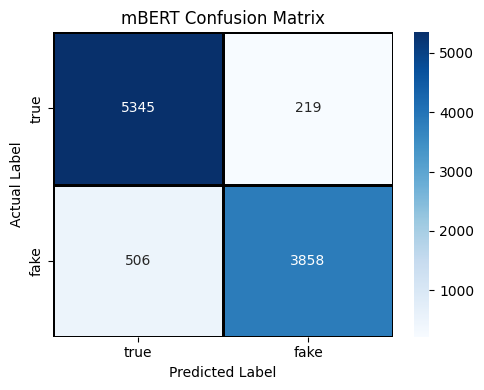

In [ ]:
cm_mbert = confusion_matrix(mbert_test_labels, mbert_test_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm_mbert, annot=True, fmt="d", cmap="Blues",
            xticklabels=["true", "fake"],
            yticklabels=["true", "fake"],
            linewidths=1, linecolor="black")
plt.title("mBERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

# 12. Model 2: XLM-RoBERTa

In [ ]:
from transformers import AutoTokenizer


In [ ]:
xlmr_model_name = "xlm-roberta-base"
xlmr_tokenizer = AutoTokenizer.from_pretrained(xlmr_model_name)

def tokenize_xlmr(batch):
    return xlmr_tokenizer(
        batch["full_text"],
        truncation=True,
        max_length=128
    )
xlmr_tokenized = dataset_dict.map(tokenize_xlmr, batched=True)
xlmr_tokenized = xlmr_tokenized.rename_column("label_num", "labels")
xlmr_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(xlmr_tokenized)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/46326 [00:00<?, ? examples/s]

Map:   0%|          | 0/9927 [00:00<?, ? examples/s]

Map:   0%|          | 0/9928 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['full_text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 46326
    })
    validation: Dataset({
        features: ['full_text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 9927
    })
    test: Dataset({
        features: ['full_text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 9928
    })
})


In [ ]:
from transformers import DataCollatorWithPadding

xlmr_data_collator = DataCollatorWithPadding(tokenizer=xlmr_tokenizer)

In [ ]:
from transformers import AutoModelForSequenceClassification


In [ ]:
xlmr_model = AutoModelForSequenceClassification.from_pretrained(
    xlmr_model_name,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments, Trainer


In [ ]:
xlmr_training_args = TrainingArguments(
    output_dir="./xlmr_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    fp16=True
)

xlmr_trainer = Trainer(
    model=xlmr_model,
    args=xlmr_training_args,
    train_dataset=xlmr_tokenized["train"],
    eval_dataset=xlmr_tokenized["validation"],
    data_collator=xlmr_data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
xlmr_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.217881,0.164503,0.931500,0.950367,0.890697,0.919565


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2896, training_loss=0.2178808391423515, metrics={'train_runtime': 618.7251, 'train_samples_per_second': 74.873, 'train_steps_per_second': 4.681, 'total_flos': 3047220687651840.0, 'train_loss': 0.2178808391423515, 'epoch': 1.0})

In [ ]:
xlmr_val_results = xlmr_trainer.evaluate(xlmr_tokenized["validation"])
print("XLM-R Validation Results:")
print(xlmr_val_results)

XLM-R Validation Results:
{'eval_loss': 0.16450326144695282, 'eval_accuracy': 0.9314999496323159, 'eval_precision': 0.9503667481662592, 'eval_recall': 0.8906966086159487, 'eval_f1': 0.9195647030991246, 'eval_runtime': 20.1468, 'eval_samples_per_second': 492.735, 'eval_steps_per_second': 30.824, 'epoch': 1.0}


In [ ]:
xlmr_test_results = xlmr_trainer.evaluate(xlmr_tokenized["test"])
print("XLM-R Test Results:")
print(xlmr_test_results)

XLM-R Test Results:
{'eval_loss': 0.1662711501121521, 'eval_accuracy': 0.9289887187751813, 'eval_precision': 0.9467643467643467, 'eval_recall': 0.8884051329055912, 'eval_f1': 0.9166568152263861, 'eval_runtime': 21.5415, 'eval_samples_per_second': 460.879, 'eval_steps_per_second': 28.828, 'epoch': 1.0}


In [ ]:
xlmr_test_pred = xlmr_trainer.predict(xlmr_tokenized["test"])
xlmr_test_preds = np.argmax(xlmr_test_pred.predictions, axis=1)
xlmr_test_labels = np.array(test_df["label_num"])

print(classification_report(xlmr_test_labels, xlmr_test_preds, target_names=["true", "fake"]))

              precision    recall  f1-score   support

        true       0.92      0.96      0.94      5564
        fake       0.95      0.89      0.92      4364

    accuracy                           0.93      9928
   macro avg       0.93      0.92      0.93      9928
weighted avg       0.93      0.93      0.93      9928



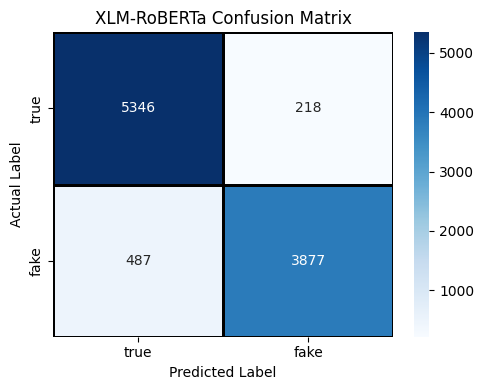

In [ ]:
cm_xlmr = confusion_matrix(xlmr_test_labels, xlmr_test_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xlmr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["true", "fake"],
            yticklabels=["true", "fake"],
            linewidths=1, linecolor="black")
plt.title("XLM-RoBERTa Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

# Compare all models

In [ ]:
comparison_df = pd.DataFrame([
    {
        "Model": "Baseline TF-IDF + Logistic Regression",
        "Accuracy": round(mbert_val_results.get("eval_accuracy", np.nan), 4) if False else round(val_acc, 4),
        "Precision": round(val_prec, 4),
        "Recall": round(val_rec, 4),
        "F1": round(val_f1, 4)
    },
    {
        "Model": "mBERT",
        "Accuracy": round(mbert_test_results["eval_accuracy"], 4),
        "Precision": round(mbert_test_results["eval_precision"], 4),
        "Recall": round(mbert_test_results["eval_recall"], 4),
        "F1": round(mbert_test_results["eval_f1"], 4)
    },
    {
        "Model": "XLM-RoBERTa",
        "Accuracy": round(xlmr_test_results["eval_accuracy"], 4),
        "Precision": round(xlmr_test_results["eval_precision"], 4),
        "Recall": round(xlmr_test_results["eval_recall"], 4),
        "F1": round(xlmr_test_results["eval_f1"], 4)
    }
])

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1
0,Baseline TF-IDF + Logistic Regression,0.8963,0.9072,0.8513,0.8784
1,mBERT,0.9270,0.9463,0.8841,0.9141
2,XLM-RoBERTa,0.9290,0.9468,0.8884,0.9167


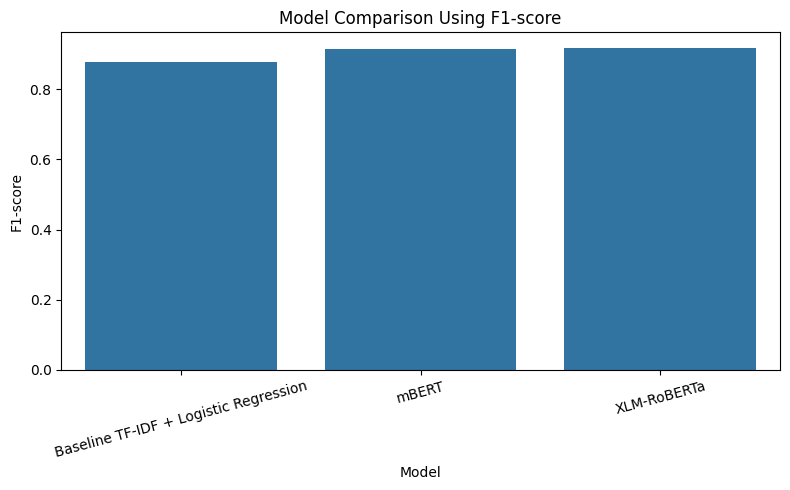

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=comparison_df, x="Model", y="F1")
plt.title("Model Comparison Using F1-score")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Language-wise test analysis

In [ ]:
test_results_df = test_df.copy().reset_index(drop=True)

test_results_df["mbert_pred"] = mbert_test_preds
test_results_df["xlmr_pred"] = xlmr_test_preds

print("mBERT language-wise performance")
for lang in test_results_df["language"].unique():
    temp = test_results_df[test_results_df["language"] == lang]
    acc = accuracy_score(temp["label_num"], temp["mbert_pred"])
    print(f"{lang}: {round(acc,4)}")

mBERT language-wise performance
english: 0.9998
hindi: 0.8719
bengali: 0.7416


In [ ]:
print("XLM-R language-wise performance")
for lang in test_results_df["language"].unique():
    temp = test_results_df[test_results_df["language"] == lang]
    acc = accuracy_score(temp["label_num"], temp["xlmr_pred"])
    print(f"{lang}: {round(acc,4)}")

XLM-R language-wise performance
english: 0.9997
hindi: 0.8857
bengali: 0.7326


# Predict on new custom samples

mBERT prediction function

In [ ]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mbert_model.to(device)
xlmr_model.to(device)

def predict_news_mbert(text):
    inputs = mbert_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        outputs = mbert_model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()

    label_map = {0: "true", 1: "fake"}
    return label_map[pred], confidence

In [ ]:
sample_text = "Breaking news: the government has officially announced a new national policy today."
pred_label, pred_conf = predict_news_mbert(sample_text)

print("mBERT Prediction:", pred_label)
print("Confidence:", round(pred_conf, 4))

mBERT Prediction: true
Confidence: 0.9977


XLM-R prediction function

In [ ]:
def predict_news_xlmr(text):
    inputs = xlmr_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        outputs = xlmr_model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()

    label_map = {0: "true", 1: "fake"}
    return label_map[pred], confidence

In [ ]:
sample_text_hi = "यह खबर पूरी तरह से झूठी है और सोशल मीडिया पर तेजी से फैल रही है।"
pred_label, pred_conf = predict_news_xlmr(sample_text_hi)

print("XLM-R Prediction:", pred_label)
print("Confidence:", round(pred_conf, 4))

XLM-R Prediction: fake
Confidence: 0.9945


# Show some real test predictions

In [ ]:
sample_test_rows = test_df[["language", "full_text", "label"]].head(10).reset_index(drop=True)

preds = []
confs = []

for txt in sample_test_rows["full_text"]:
    label_pred, conf_pred = predict_news_xlmr(txt)
    preds.append(label_pred)
    confs.append(round(conf_pred, 4))

sample_test_rows["predicted_label"] = preds
sample_test_rows["confidence"] = confs

display(sample_test_rows)

,language,full_text,label,predicted_label,confidence
0,english,Australian PM says nine foreigners among those...,true,true,0.9998
1,hindi,फ़ोट थाईलैंड के शहर बैंगकॉक बाल इंडोनेशिय शिव म...,fake,fake,0.9995
2,hindi,लोगों के बीच से कोरोना महामारी का भय खत्म करना...,true,true,0.8701
3,hindi,क्या मोबाइल से भी कोरोना का खतरा हो सकता है,true,true,0.9438
4,english,Trump packs transition team with loyalists and...,true,true,0.9999
5,hindi,जॉर्जटाउन विश्वविद्यालय में शनिवार को हुए एक क...,true,true,0.9509
6,english,Official photo released to mark 70th wedding a...,true,true,0.9998
7,bengali,অবসরে পাকিস্তানি স্পিনার আবদুর রেহমান একটা সময়...,true,true,0.6141
8,hindi,हाउस ऑफ कॉमन्स ने यूरोपीय संघ वापसी की अधिसूचन...,fake,true,0.8947
9,bengali,বংগবন্ধুর পিত্তথলির পাথরের স্মৃতি অমলিন: মকসুদ...,fake,fake,0.9993


# Save best model

In [ ]:
import torch

# make sure eval mode
xlmr_model.eval()

# save smaller half-precision weights
state_dict_fp16 = {k: v.half() for k, v in xlmr_model.state_dict().items()}
torch.save(state_dict_fp16, "xlmr_fake_news_fp16.pth")

print("Saved smaller file: xlmr_fake_news_fp16.pth")

Saved smaller file: xlmr_fake_news_fp16.pth
